[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter3_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 3: Factor Models and Asset Pricing

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces the charts and numbers of Lecture 3, except the case study and the AI mini-case:
- US sector and factor ETFs, SPY, Bucharest Stock Exchange blue chips and BET (daily prices provided with the course);
- Fama–French factors, momentum and the 25 size × book-to-market portfolios (Kenneth French Data Library).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/2026 MFM/MFM/notebooks/EN


In [2]:
import os
import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Data

- ETFs and stocks: adjusted prices; indices (BET): closing values.
- Multi-asset analyses first align the **prices** on common days, then compute returns.
- The French data are in percent: they are divided by 100.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'

SECTORS = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']        # from Dec 1998
SECTORS_ALL = SECTORS + ['XLRE', 'XLC']                                           # XLRE 2015, XLC 2018
SECTOR_NAMES = {'XLB': 'Materials', 'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
                'XLK': 'Technology', 'XLP': 'Cons. staples', 'XLU': 'Utilities', 'XLV': 'Health care',
                'XLY': 'Cons. discretionary', 'XLRE': 'Real estate', 'XLC': 'Communication'}
FACTOR_ETFS = ['MTUM', 'VLUE', 'QUAL', 'USMV', 'IWM', 'IWD', 'IWF']
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'FP', 'SNG', 'H2O', 'SNN', 'EL', 'DIGI', 'TEL']
BVB_NAMES = {'TLV': 'Banca Transilvania', 'SNP': 'OMV Petrom', 'BRD': 'BRD-GSG', 'TGN': 'Transgaz',
             'FP': 'Fondul Proprietatea', 'SNG': 'Romgaz', 'H2O': 'Hidroelectrica', 'SNN': 'Nuclearelectrica',
             'EL': 'Electrica', 'DIGI': 'Digi', 'TEL': 'Transelectrica'}

_CACHE = {}


def read_market(symbol):
    """Daily prices of one asset from the course data."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(symbol):
    """Price used: adjusted close for ETFs and stocks, close for indices."""
    d = read_market(symbol)
    col = 'close' if symbol.endswith('.INDX') or symbol == 'BET' else 'adjusted_close'
    s = d[col].astype(float)
    return s[s > 0].rename(symbol)


def prices(symbols, start=None, end=None):
    """Prices aligned on the common days (multi-asset analyses align prices before taking returns)."""
    p = pd.concat([price(s) for s in symbols], axis=1).dropna()
    return p.loc[start:end]


def log_returns(p):
    """Log returns of an already aligned table (common days)."""
    return np.log(p).diff().dropna()


# =============================================================================
# KENNETH FRENCH DATA LIBRARY
# =============================================================================
FILES = {
    ('ff3', 'M'): 'F-F_Research_Data_Factors_CSV.zip',
    ('ff3', 'D'): 'F-F_Research_Data_Factors_daily_CSV.zip',
    ('ff5', 'M'): 'F-F_Research_Data_5_Factors_2x3_CSV.zip',
    ('ff5', 'D'): 'F-F_Research_Data_5_Factors_2x3_daily_CSV.zip',
    ('mom', 'M'): 'F-F_Momentum_Factor_CSV.zip',
    ('mom', 'D'): 'F-F_Momentum_Factor_daily_CSV.zip',
    ('p25', 'M'): '25_Portfolios_5x5_CSV.zip',
    ('ind10', 'M'): '10_Industry_Portfolios_CSV.zip',
    ('ind30', 'M'): '30_Industry_Portfolios_CSV.zip',
    ('p100', 'M'): '100_Portfolios_10x10_CSV.zip',
    # univariate sorts (first table: value-weighted), Jensen-Kelly-Pedersen case study
    ('ME', 'M'): 'Portfolios_Formed_on_ME_CSV.zip',
    ('BE-ME', 'M'): 'Portfolios_Formed_on_BE-ME_CSV.zip',
    ('OP', 'M'): 'Portfolios_Formed_on_OP_CSV.zip',
    ('INV', 'M'): 'Portfolios_Formed_on_INV_CSV.zip',
    ('E-P', 'M'): 'Portfolios_Formed_on_E-P_CSV.zip',
    ('CF-P', 'M'): 'Portfolios_Formed_on_CF-P_CSV.zip',
    ('D-P', 'M'): 'Portfolios_Formed_on_D-P_CSV.zip',
    ('AC', 'M'): 'Portfolios_Formed_on_AC_CSV.zip',
    ('NI', 'M'): 'Portfolios_Formed_on_NI_CSV.zip',
    ('BETA', 'M'): 'Portfolios_Formed_on_BETA_CSV.zip',
    ('VAR', 'M'): 'Portfolios_Formed_on_VAR_CSV.zip',
    ('RESVAR', 'M'): 'Portfolios_Formed_on_RESVAR_CSV.zip',
    ('PRIOR_12_2', 'M'): '10_Portfolios_Prior_12_2_CSV.zip',
    ('PRIOR_1_0', 'M'): '10_Portfolios_Prior_1_0_CSV.zip',
    ('PRIOR_60_13', 'M'): '10_Portfolios_Prior_60_13_CSV.zip',
}


def _parse_first_table(text, date_len):
    """First table of a French data set: header ',col1,col2...', then rows YYYYMM(DD),values."""
    lines = text.splitlines()
    i = next(k for k, l in enumerate(lines) if l.startswith(',') and len(l.split(',')) > 1)
    cols = [c.strip() for c in lines[i].split(',')[1:]]
    rows = []
    for l in lines[i + 1:]:
        parts = [x.strip() for x in l.split(',')]
        if not parts or len(parts[0]) != date_len or not parts[0].isdigit():
            break
        rows.append([parts[0]] + [float(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=['date'] + cols)
    fmt = '%Y%m' if date_len == 6 else '%Y%m%d'
    df['date'] = pd.to_datetime(df['date'], format=fmt)
    if date_len == 6:
        df['date'] = df['date'] + pd.offsets.MonthEnd(0)
    df = df.set_index('date')
    return df.replace([-99.99, -999.0], np.nan) / 100.0          # percent -> decimal


def french(name='ff5', freq='M'):
    """Fama-French factors / momentum / portfolios, in decimals (0.01 = 1%)."""
    key = (name, freq)
    if key in _CACHE:
        return _CACHE[key]
    url = FRENCH + FILES[key]
    raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    text = z.read(z.namelist()[0]).decode('latin-1')
    df = _parse_first_table(text, 6 if freq == 'M' else 8)
    df.columns = [c.replace('Mom', 'MOM').strip() for c in df.columns]
    _CACHE[key] = df
    return df


def factors(freq='M'):
    """Mkt-RF, SMB, HML, RMW, CMA, RF, MOM and SMB_FF3 over the common period.

    The five-factor SMB (sorts on B/M, profitability and investment) enters FF5;
    SMB_FF3 is the published three-factor SMB (2x3 sorts on size and B/M),
    used in FF3 and Carhart. HML, Mkt-RF and RF are the same in the two data sets.
    """
    f3 = french('ff3', freq)[['SMB']].rename(columns={'SMB': 'SMB_FF3'})
    return pd.concat([french('ff5', freq), french('mom', freq), f3], axis=1).dropna()


# =============================================================================
# REGRESSIONS
# =============================================================================
def ols_hac(y, X, lags=None, const=True):
    """OLS with Newey-West (Bartlett) standard errors. Returns (coef, se, t, resid, r2)."""
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    if X.ndim == 1:
        X = X[:, None]
    if const:
        X = np.column_stack([np.ones(len(y)), X])
    n, k = X.shape
    if lags is None:
        lags = int(np.floor(4 * (n / 100) ** (2 / 9)))
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    e = y - X @ b
    u = X * e[:, None]
    S = u.T @ u
    for l in range(1, lags + 1):
        w = 1 - l / (lags + 1)
        G = u[l:].T @ u[:-l]
        S += w * (G + G.T)
    V = XtX_inv @ S @ XtX_inv
    se = np.sqrt(np.diag(V))
    r2 = 1 - e.var() / y.var()
    return b, se, b / se, e, r2


def grs_test(excess, market_excess):
    """Gibbons-Ross-Shanken (1989) test of alpha = 0 on N assets, one factor.

    Sigma and the factor variance are maximum-likelihood estimators (division by T);
    under i.i.d. Normal residuals, W ~ F(N, T - N - 1) exactly.
    """
    from scipy import stats
    R = np.asarray(excess, float)
    f = np.asarray(market_excess, float)
    T, N = R.shape
    X = np.column_stack([np.ones(T), f])
    B = np.linalg.lstsq(X, R, rcond=None)[0]
    alpha = B[0]
    E = R - X @ B
    Sigma = E.T @ E / T
    mu, s2 = f.mean(), f.var(ddof=0)
    stat = (T - N - 1) / N * (alpha @ np.linalg.solve(Sigma, alpha)) / (1 + mu ** 2 / s2)
    p = 1 - stats.f.cdf(stat, N, T - N - 1)
    return stat, p, alpha, B[1]

## Return conventions, style and helpers

- Monthly excess returns: month-end prices, simple returns minus the one-month T-bill rate (RF).
- Daily excess returns of one ETF: only returns between consecutive factor trading days.

In [4]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
PALETTE = [MainBlue, IDAred, Forest, Amber, Orange, Purple, Crimson, '#795548', '#17A2B8', '#6F42C1', '#20C997']

# models: FF3 and Carhart use the published three-factor SMB; FF5 uses the five-factor SMB
FF3 = ['Mkt-RF', 'SMB_FF3', 'HML']
CARHART = FF3 + ['MOM']
FF5 = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
FF6 = FF5 + ['MOM']

SEED = 42
MAX_ABS_RET = 0.5        # data-error threshold for the BVB series (daily log return)
END = '2026-07-31'       # last month of the monthly sample used in the chapter (T = 757 months from July 1963)


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def monthly_excess(symbols, start='1999-01-01'):
    """Monthly simple excess returns over RF (one-month T-bill), on the common months."""
    p = prices(symbols).resample('ME').last()
    r = p.pct_change().dropna()
    F = factors('M')
    idx = r.index.intersection(F.index)
    r = r.loc[idx].loc[start:END]
    F = F.loc[r.index]
    return r.sub(F['RF'], axis=0), F


def daily_excess_one(symbol, start=None):
    """Daily excess return of a single asset, on the factor calendar.

    Only days with a price on the previous trading day are kept
    (otherwise the return would span several days and the factors only one).
    """
    s = price(symbol)
    F = factors('D').loc[:END]                         # same sample end as the monthly data
    s = s.loc[s.index.isin(F.index)]
    cal = pd.Series(np.arange(len(F)), index=F.index)
    pos = cal.loc[s.index].values
    r = s.pct_change()
    consecutive = np.r_[False, np.diff(pos) == 1]
    r = r[consecutive].dropna()
    if start:
        r = r.loc[start:]
    Fx = F.loc[r.index]
    return (r - Fx['RF']).rename(symbol), Fx


def daily_excess(symbols, start=None):
    """Compatibility: dictionary {symbol: (excess, factors)} on each asset's calendar."""
    return {s: daily_excess_one(s, start) for s in symbols}


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## 1. From Markowitz to the CAPM: the efficient frontier of US sectors

- Tangency portfolio $\mathbf{w} \propto \boldsymbol\Sigma^{-1}\boldsymbol\mu$; Sharpe ratio $SR = \mathbb{E}[R - R_f]/\sigma$.

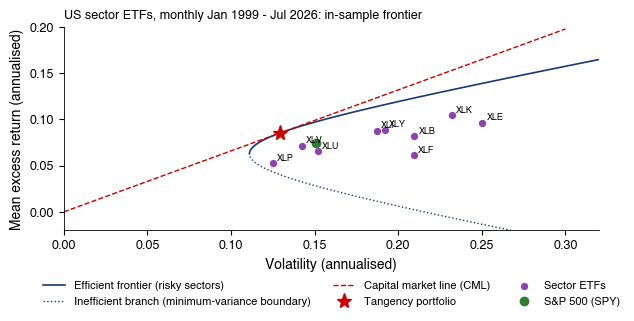

{'start': '1999-01-31',
 'end': '2026-07-31',
 'T': 331,
 'tan_mu': np.float64(0.08547106608069018),
 'tan_sd': np.float64(0.12956629364189368),
 'tan_sr': np.float64(0.6596705337340464),
 'spy_sr': np.float64(0.49319091775728513),
 'spy_mu': np.float64(0.07438851815443036),
 'spy_sd': np.float64(0.15083107874877635),
 'w_tan': {'XLB': -0.207,
  'XLE': 0.194,
  'XLF': -0.372,
  'XLI': 0.179,
  'XLK': 0.125,
  'XLP': 0.155,
  'XLU': 0.266,
  'XLV': 0.372,
  'XLY': 0.288},
 'w_neg': 2}

In [5]:
def fig_frontier():
    S = [s + '.US' for s in SECTORS]
    ex, F = monthly_excess(S + ['SPY.US'])
    mu = ex[S].mean().values * 12
    cov = ex[S].cov().values * 12
    ones = np.ones(len(S))
    inv = np.linalg.inv(cov)
    w_tan = inv @ mu / (ones @ inv @ mu)
    mu_t, sd_t = w_tan @ mu, np.sqrt(w_tan @ cov @ w_tan)
    # unconstrained frontier in excess-return space
    A, B, C = ones @ inv @ ones, ones @ inv @ mu, mu @ inv @ mu
    targets = np.linspace(-0.02, 0.20, 200)
    sd_f = np.sqrt((A * targets ** 2 - 2 * B * targets + C) / (A * C - B ** 2))
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    eff = targets >= B / A                               # efficient branch: mean >= mean of the minimum-variance portfolio
    ax.plot(sd_f[eff], targets[eff], color=MainBlue, lw=1.2, label='Efficient frontier (risky sectors)')
    ax.plot(sd_f[~eff], targets[~eff], color=MainBlue, lw=1.0, ls=':', label='Inefficient branch (minimum-variance boundary)')
    xs = np.linspace(0, 0.30, 50)
    ax.plot(xs, mu_t / sd_t * xs, color=IDAred, lw=1.0, ls='--', label='Capital market line (CML)')
    ax.plot(sd_t, mu_t, '*', ms=11, color=IDAred, label='Tangency portfolio')
    sd_i = np.sqrt(np.diag(cov))
    ax.scatter(sd_i, mu, s=18, color=Purple, zorder=3, label='Sector ETFs')
    for s, x, y in zip(SECTORS, sd_i, mu):
        ax.annotate(s, (x, y), xytext=(3, 2), textcoords='offset points', fontsize=6.5, color='black')
    spy_mu, spy_sd = ex['SPY.US'].mean() * 12, ex['SPY.US'].std() * np.sqrt(12)
    ax.plot(spy_sd, spy_mu, 'o', ms=6, color=Forest, label='S&P 500 (SPY)')
    ax.set_xlim(0, 0.32)
    ax.set_ylim(-0.02, 0.20)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean excess return (annualised)')
    ax.set_title(f'US sector ETFs, monthly {ex.index[0]:%b %Y} - {ex.index[-1]:%b %Y}: in-sample frontier',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save_fig('ch3_frontier')
    w = pd.Series(w_tan, index=SECTORS)
    return dict(start=str(ex.index[0].date()), end=str(ex.index[-1].date()), T=len(ex),
                tan_mu=mu_t, tan_sd=sd_t, tan_sr=mu_t / sd_t, spy_sr=spy_mu / spy_sd,
                spy_mu=spy_mu, spy_sd=spy_sd, w_tan=w.round(3).to_dict(),
                w_neg=int((w < 0).sum()))


fig_frontier()

## 2. Estimating beta

- Rolling 252-day betas; Blume and Vasicek shrinkage; BVB blue chips vs BET.

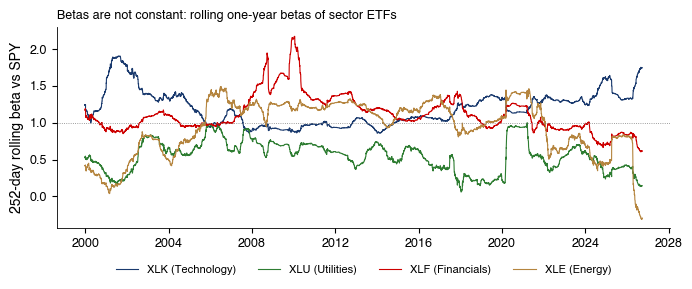

{'XLK': {'min': 0.8571078937477423,
  'max': 1.9043987052314573,
  'last': 1.7455945184598844},
 'XLU': {'min': 0.059145441320352814,
  'max': 0.9997646407325816,
  'last': 0.1467223231886952},
 'XLF': {'min': 0.6041280413283017,
  'max': 2.171711568839296,
  'last': 0.6141389301949327},
 'XLE': {'min': -0.30989154058061164,
  'max': 1.4896376606943942,
  'last': -0.291595900605115}}

In [6]:
def fig_rolling_beta(window=252):
    S = ['XLK.US', 'XLU.US', 'XLF.US', 'XLE.US']
    r = log_returns(prices(S + ['SPY.US']))
    m = r['SPY.US']
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    out = {}
    for s, c in zip(S, [MainBlue, Forest, IDAred, Amber]):
        b = r[s].rolling(window).cov(m) / m.rolling(window).var()
        ax.plot(b.index, b.values, color=c, lw=0.8, label=f'{s[:-3]} ({SECTOR_NAMES[s[:-3]]})')
        out[s[:-3]] = dict(min=float(b.min()), max=float(b.max()), last=float(b.dropna().iloc[-1]))
    ax.axhline(1, color=Gray, lw=0.6, ls=':')
    ax.set_ylabel('252-day rolling beta vs SPY')
    ax.set_title('Betas are not constant: rolling one-year betas of sector ETFs', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.13)
    plt.tight_layout()
    save_fig('ch3_rolling_beta')
    return out


fig_rolling_beta()

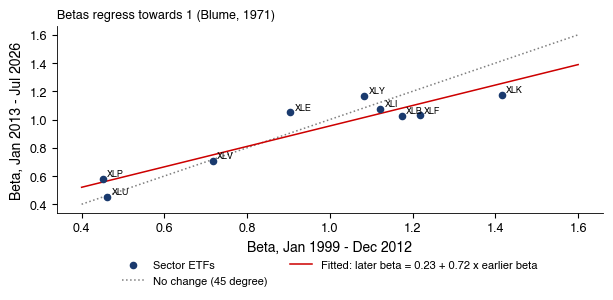

{'slope': np.float64(0.7241724887901937),
 'icpt': np.float64(0.23044793303727698),
 'rmse_raw': 0.13471984494507508,
 'rmse_blume': 0.10925855446576165,
 'rmse_vasicek': 0.11364291689920006,
 'prior_mean': 0.9494604188301623,
 'prior_var': 0.10822100120774544,
 'var_cs': 0.11594888607543398,
 'mean_se2': 0.007727884867688538,
 'betas1': {'XLB': 1.174,
  'XLE': 0.904,
  'XLF': 1.217,
  'XLI': 1.122,
  'XLK': 1.415,
  'XLP': 0.451,
  'XLU': 0.463,
  'XLV': 0.716,
  'XLY': 1.083},
 'se1': {'XLB': 0.083,
  'XLE': 0.089,
  'XLF': 0.12,
  'XLI': 0.057,
  'XLK': 0.139,
  'XLP': 0.064,
  'XLU': 0.086,
  'XLV': 0.047,
  'XLY': 0.063},
 'betas2': {'XLB': 1.026,
  'XLE': 1.051,
  'XLF': 1.029,
  'XLI': 1.078,
  'XLK': 1.172,
  'XLP': 0.578,
  'XLU': 0.455,
  'XLV': 0.705,
  'XLY': 1.169},
 'vasicek': {'XLB': 1.161,
  'XLE': 0.907,
  'XLF': 1.185,
  'XLI': 1.117,
  'XLK': 1.344,
  'XLP': 0.47,
  'XLU': 0.494,
  'XLV': 0.721,
  'XLY': 1.078}}

In [7]:
def beta_split():
    S = [s + '.US' for s in SECTORS]
    ex, F = monthly_excess(S + ['SPY.US'])
    halves = [ex.loc[:'2012-12-31'], ex.loc['2013-01-01':]]
    b = []
    for h in halves:
        b.append(pd.Series({s[:-3]: ols_hac(h[s].values, h['SPY.US'].values)[0][1] for s in S}))
    se1 = pd.Series({s[:-3]: ols_hac(halves[0][s].values, halves[0]['SPY.US'].values)[1][1] for s in S})
    return b[0], b[1], se1, halves


def vasicek_prior(b, se):
    """Vasicek prior estimated from the data (empirical Bayes).

    Var_cs(beta_hat) = Var_cs(beta) + mean se^2: the dispersion of estimated betas includes estimation noise,
    so the prior variance of the true betas is Var_cs(beta_hat) - mean se(beta_hat)^2.
    """
    m = float(b.mean())
    v = float(b.var(ddof=1) - (se ** 2).mean())
    return m, max(v, 1e-6)


def fig_beta_shrink():
    b1, b2, se1, halves = beta_split()
    slope, icpt = np.polyfit(b1, b2, 1)
    # Vasicek (empirical Bayes): prior mean = cross-sectional mean of the estimated betas;
    # prior variance = cross-sectional variance of the estimated betas MINUS the mean estimation noise
    prior_m, prior_v = vasicek_prior(b1, se1)
    w = prior_v / (prior_v + se1 ** 2)
    b_vas = w * b1 + (1 - w) * prior_m
    b_blume = 0.67 * b1 + 0.33
    err = lambda x: float(np.sqrt(((x - b2) ** 2).mean()))
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    ax.scatter(b1, b2, s=20, color=MainBlue, zorder=3, label='Sector ETFs')
    for s in b1.index:
        ax.annotate(s, (b1[s], b2[s]), xytext=(3, 2), textcoords='offset points', fontsize=6.5, color='black')
    xs = np.linspace(0.4, 1.6, 10)
    ax.plot(xs, xs, color=Gray, ls=':', label='No change (45 degree)')
    ax.plot(xs, icpt + slope * xs, color=IDAred, label=f'Fitted: later beta = {icpt:.2f} + {slope:.2f} x earlier beta')
    ax.set_xlabel('Beta, Jan 1999 - Dec 2012')
    ax.set_ylabel('Beta, Jan 2013 - Jul 2026')
    ax.set_title('Betas regress towards 1 (Blume, 1971)', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    plt.tight_layout()
    save_fig('ch3_beta_shrink')
    return dict(slope=slope, icpt=icpt, rmse_raw=err(b1), rmse_blume=err(b_blume), rmse_vasicek=err(b_vas),
                prior_mean=prior_m, prior_var=prior_v, var_cs=float(b1.var(ddof=1)),
                mean_se2=float((se1 ** 2).mean()), betas1=b1.round(3).to_dict(), se1=se1.round(3).to_dict(), betas2=b2.round(3).to_dict(),
                vasicek=b_vas.round(3).to_dict())


fig_beta_shrink()

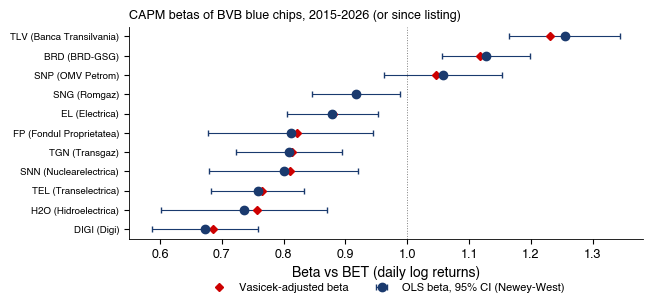

[{'stock': 'DIGI',
  'beta': 0.673,
  'se': 0.044,
  'r2': 0.208,
  'n': 2326,
  'from': '2017-05-18',
  'n_removed': 1,
  'vasicek': 0.687},
 {'stock': 'H2O',
  'beta': 0.737,
  'se': 0.069,
  'r2': 0.313,
  'n': 792,
  'from': '2023-07-13',
  'n_removed': 0,
  'vasicek': 0.758},
 {'stock': 'TEL',
  'beta': 0.758,
  'se': 0.039,
  'r2': 0.245,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.764},
 {'stock': 'SNN',
  'beta': 0.8,
  'se': 0.061,
  'r2': 0.29,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.81},
 {'stock': 'TGN',
  'beta': 0.809,
  'se': 0.044,
  'r2': 0.3,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.814},
 {'stock': 'FP',
  'beta': 0.811,
  'se': 0.068,
  'r2': 0.328,
  'n': 2923,
  'from': '2015-01-06',
  'n_removed': 2,
  'vasicek': 0.822},
 {'stock': 'EL',
  'beta': 0.879,
  'se': 0.038,
  'r2': 0.3,
  'n': 2925,
  'from': '2015-01-06',
  'n_removed': 0,
  'vasicek': 0.879},
 {'stock': 'SNG',
  'be

In [8]:
def bvb_betas(start='2015-01-01'):
    rows = []
    for s in BVB:
        p = prices([s + '.RO', 'BET']).loc[start:]
        r = log_returns(p)
        # data errors (unadjusted capital events): days with |r| > 50% are removed
        bad = (r.abs() > MAX_ABS_RET).any(axis=1)
        r = r[~bad]
        b, se, t, e, r2 = ols_hac(r[s + '.RO'].values, r['BET'].values)
        rows.append((s, b[1], se[1], r2, len(r), str(r.index[0].date()), int(bad.sum())))
    res = pd.DataFrame(rows, columns=['stock', 'beta', 'se', 'r2', 'n', 'from', 'n_removed']).set_index('stock')
    prior_m, prior_v = vasicek_prior(res['beta'], res['se'])
    w = prior_v / (prior_v + res['se'] ** 2)
    res['vasicek'] = w * res['beta'] + (1 - w) * prior_m
    return res.sort_values('beta')


def fig_bvb_betas():
    res = bvb_betas()
    y = np.arange(len(res))
    fig, ax = plt.subplots(figsize=(6.6, 3.2))
    ax.errorbar(res['beta'], y, xerr=1.96 * res['se'], fmt='o', color=MainBlue, capsize=2, lw=0.8,
                label='OLS beta, 95% CI (Newey-West)')
    ax.plot(res['vasicek'], y, 'D', ms=4, color=IDAred, label='Vasicek-adjusted beta')
    ax.axvline(1, color=Gray, ls=':', lw=0.7)
    ax.set_yticks(y, [f'{s} ({BVB_NAMES[s]})' for s in res.index], fontsize=7)
    ax.set_xlabel('Beta vs BET (daily log returns)')
    ax.set_title('CAPM betas of BVB blue chips, 2015-2026 (or since listing)', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    plt.tight_layout()
    save_fig('ch3_bvb_betas')
    return res.round(3).reset_index().to_dict(orient='records')


fig_bvb_betas()

## 3. Testing the CAPM: security market line and GRS test

- 25 size × book-to-market portfolios, monthly 1963–2026; $W = \frac{T-N-1}{N}\frac{\hat\alpha'\hat\Sigma^{-1}\hat\alpha}{1+\hat\mu_m^2/\hat\sigma_m^2}$.

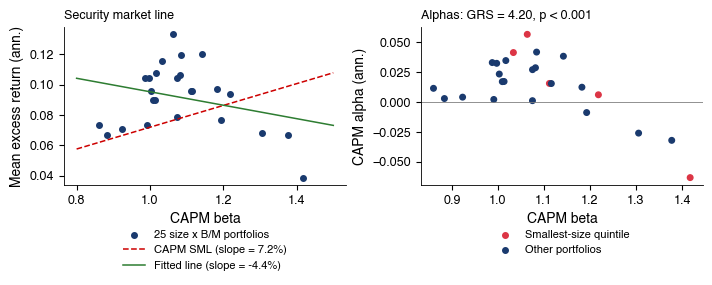

{'start': '1963-07-31',
 'end': '2026-07-31',
 'T': 757,
 'prem': np.float64(0.07190647291941878),
 'slope': np.float64(-0.04441807673471126),
 'icpt': np.float64(0.13975394211712563),
 'beta_min': 0.8600472630976725,
 'beta_max': 1.4175523804928558,
 'avg_min': 0.03865236459709379,
 'avg_max': 0.13322927873183618,
 'grs': np.float64(4.195714717258486),
 'grs_p': np.float64(7.505407406682707e-11),
 'n_sig': 10,
 'alpha_smallvalue': np.float64(0.05673893540172637),
 'alpha_smallgrowth': np.float64(-0.0632788272626733)}

In [9]:
def sml_data(start='1963-07-31'):
    F = factors('M')
    P = french('p25', 'M').loc[start:END]
    Fx = F.loc[P.index]
    ex = P.sub(Fx['RF'], axis=0)
    mk = Fx['Mkt-RF']
    rows = []
    for c in ex.columns:
        b, se, t, e, r2 = ols_hac(ex[c].values, mk.values)
        rows.append((c, b[1], b[0] * 12, t[0], ex[c].mean() * 12))
    res = pd.DataFrame(rows, columns=['port', 'beta', 'alpha', 't_alpha', 'avg']).set_index('port')
    return res, ex, mk


def fig_sml():
    res, ex, mk = sml_data()
    prem = mk.mean() * 12
    slope, icpt = np.polyfit(res['beta'], res['avg'], 1)
    stat, pv, _, _ = grs_test(ex.values, mk.values)
    small = [c for c in res.index if c.startswith('SMALL') or c.startswith('ME1')]
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1))
    ax = axes[0]
    ax.scatter(res['beta'], res['avg'], s=16, color=MainBlue, label='25 size x B/M portfolios')
    xs = np.linspace(0.8, 1.5, 10)
    ax.plot(xs, prem * xs, color=IDAred, ls='--', label=f'CAPM SML (slope = {prem:.1%})')
    ax.plot(xs, icpt + slope * xs, color=Forest, label=f'Fitted line (slope = {slope:.1%})')
    ax.set_xlabel('CAPM beta')
    ax.set_ylabel('Mean excess return (ann.)')
    ax.set_title('Security market line', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.22)
    ax = axes[1]
    col = [Crimson if c in small else MainBlue for c in res.index]
    ax.scatter(res['beta'], res['alpha'], s=16, c=col)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('CAPM beta')
    ax.set_ylabel('CAPM alpha (ann.)')
    ax.set_title(f'Alphas: GRS = {stat:.2f}, p < 0.001', fontsize=9, loc='left')
    ax.scatter([], [], s=16, color=Crimson, label='Smallest-size quintile')
    ax.scatter([], [], s=16, color=MainBlue, label='Other portfolios')
    legend_outside_bottom(ax, ncol=1, y=-0.22)
    plt.tight_layout()
    save_fig('ch3_sml')
    return dict(start=str(ex.index[0].date()), end=str(ex.index[-1].date()), T=len(ex), prem=prem,
                slope=slope, icpt=icpt, beta_min=res['beta'].min(), beta_max=res['beta'].max(),
                avg_min=res['avg'].min(), avg_max=res['avg'].max(), grs=stat, grs_p=pv,
                n_sig=int((res['t_alpha'].abs() > 1.96).sum()),
                alpha_smallvalue=res.loc['SMALL HiBM', 'alpha'], alpha_smallgrowth=res.loc['SMALL LoBM', 'alpha'])


fig_sml()

### GRS as a Sharpe-ratio test

- $\hat\alpha'\hat\Sigma^{-1}\hat\alpha = \widehat{SR}^2(f, R) - \widehat{SR}^2(f)$ with maximum-likelihood moments.

In [10]:
def grs_sharpe(ex, mk):
    """GRS identity: alpha' Sigma^-1 alpha = SR^2(f, R) - SR^2(f) (ML estimators, division by T)."""
    R = np.asarray(ex, float)
    f = np.asarray(mk, float)
    T, N = R.shape
    Y = np.column_stack([f, R])
    m = Y.mean(0)
    V = np.cov(Y.T, ddof=0)
    sr2_all = m @ np.linalg.solve(V, m)
    sr2_f = f.mean() ** 2 / f.var(ddof=0)
    stat, p, _, _ = grs_test(R, f)
    W_id = (T - N - 1) / N * (sr2_all - sr2_f) / (1 + sr2_f)
    return dict(T=T, N=N, sr_f_m=np.sqrt(sr2_f), sr_all_m=np.sqrt(sr2_all), sr_f_ann=np.sqrt(12 * sr2_f),
                sr_all_ann=np.sqrt(12 * sr2_all), grs=stat, grs_p=p, grs_identity=W_id)


res, ex, mk = sml_data()
grs_sharpe(ex.values, mk.values)

{'T': 757,
 'N': 25,
 'sr_f_m': np.float64(0.13443367571797993),
 'sr_all_m': np.float64(0.4051641156464056),
 'sr_f_ann': np.float64(0.46569191318355935),
 'sr_all_ann': np.float64(1.4035296674065736),
 'grs': np.float64(4.195714717258486),
 'grs_p': np.float64(7.505407406682707e-11),
 'grs_identity': np.float64(4.195714717258482)}

## 4. Fama–MacBeth regressions

- Pass 1: time-series betas; Pass 2: monthly cross-sectional slopes, averaged.
- Standard errors: Fama–MacBeth, Newey–West (6 lags, the rule for T = 757) and Shanken, $\mathrm{Var}_{Sh} = (1+c)(\mathrm{Var}_{FM} - \Sigma_f/T) + \Sigma_f/T$.

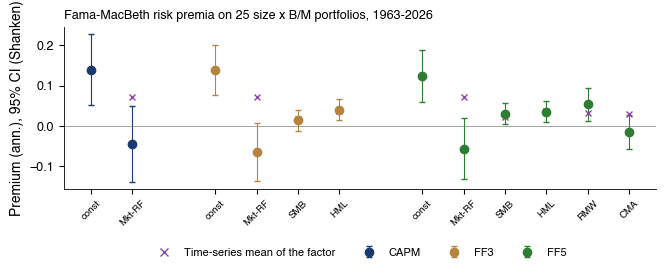

{'CAPM': [{'index': 'const',
   'lambda': 0.1398,
   'se_fm': 0.0444,
   'se_nw': 0.0479,
   'se_shanken': 0.0445,
   'factor_mean': nan},
  {'index': 'Mkt-RF',
   'lambda': -0.0444,
   'se_fm': 0.0477,
   'se_nw': 0.0514,
   'se_shanken': 0.0479,
   'factor_mean': 0.0719}],
 'FF3': [{'index': 'const',
   'lambda': 0.1386,
   'se_fm': 0.031,
   'se_nw': 0.032,
   'se_shanken': 0.0314,
   'factor_mean': nan},
  {'index': 'Mkt-RF',
   'lambda': -0.0654,
   'se_fm': 0.0365,
   'se_nw': 0.0357,
   'se_shanken': 0.0368,
   'factor_mean': 0.0719},
  {'index': 'SMB_FF3',
   'lambda': 0.0139,
   'se_fm': 0.0135,
   'se_nw': 0.014,
   'se_shanken': 0.0135,
   'factor_mean': 0.0177},
  {'index': 'HML',
   'lambda': 0.0397,
   'se_fm': 0.0133,
   'se_nw': 0.0162,
   'se_shanken': 0.0133,
   'factor_mean': 0.0359}],
 'FF5': [{'index': 'const',
   'lambda': 0.1244,
   'se_fm': 0.0314,
   'se_nw': 0.0298,
   'se_shanken': 0.033,
   'factor_mean': nan},
  {'index': 'Mkt-RF',
   'lambda': -0.0566,
   

In [11]:
def fama_macbeth(ex, F, fac, nw_lags=6):
    """Pass 1: full-sample betas; pass 2: monthly cross-sectional regressions."""
    X = F[fac].values
    B = np.linalg.lstsq(np.column_stack([np.ones(len(X)), X]), ex.values, rcond=None)[0][1:].T   # N x K
    lam = []
    for t in range(len(ex)):
        Z = np.column_stack([np.ones(B.shape[0]), B])
        lam.append(np.linalg.lstsq(Z, ex.values[t], rcond=None)[0])
    lam = np.array(lam)                                   # T x (1+K)
    mean = lam.mean(0)
    se_fm = lam.std(0, ddof=1) / np.sqrt(len(lam))
    se_nw = np.array([ols_hac(lam[:, j], np.zeros((len(lam), 0)), lags=nw_lags)[1][0] for j in range(lam.shape[1])])
    # Shanken (1992) correction: the FM variance already contains Sigma_f / T (factor variation);
    # only the remainder (the idiosyncratic part) is multiplied by (1 + c), c = lambda' Sigma_f^-1 lambda:
    # Var_Sh = (1 + c) (Var_FM - Sigma_f* / T) + Sigma_f* / T, Sigma_f* = Sigma_f bordered with zeros for the intercept
    Sf = np.atleast_2d(np.cov(X.T))
    c = mean[1:] @ np.linalg.solve(Sf, mean[1:])
    sf_diag = np.r_[0.0, np.diag(Sf)] / len(lam)
    se_sh = np.sqrt((1 + c) * (se_fm ** 2 - sf_diag) + sf_diag)
    return pd.DataFrame({'lambda': mean * 12, 'se_fm': se_fm * 12, 'se_nw': se_nw * 12, 'se_shanken': se_sh * 12,
                         'factor_mean': np.r_[np.nan, X.mean(0) * 12]}, index=['const'] + fac)


def fig_fama_macbeth():
    res, ex, mk = sml_data()
    F = factors('M').loc[ex.index]
    models = {'CAPM': ['Mkt-RF'], 'FF3': FF3, 'FF5': FF5}
    out = {k: fama_macbeth(ex, F, v) for k, v in models.items()}
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    labels, x0 = [], 0
    for k, c in zip(models, [MainBlue, Amber, Forest]):
        d = out[k]
        xs = np.arange(len(d)) + x0
        ax.errorbar(xs, d['lambda'], yerr=1.96 * d['se_shanken'], fmt='o', color=c, capsize=2, lw=0.8, label=k)
        ax.plot(xs[1:], d['factor_mean'].iloc[1:], 'x', color=Purple, ms=5)
        labels += [f'{k}: {n.replace("SMB_FF3", "SMB")}' for n in d.index]
        x0 += len(d) + 1
    ax.plot([], [], 'x', color=Purple, label='Time-series mean of the factor')
    ax.axhline(0, color=Gray, lw=0.5)
    ticks = []
    x0 = 0
    for k in models:
        ticks += list(np.arange(len(out[k])) + x0)
        x0 += len(out[k]) + 1
    ax.set_xticks(ticks, [l.split(': ')[1] for l in labels], rotation=45, fontsize=7)
    ax.set_ylabel('Premium (ann.), 95% CI (Shanken)')
    ax.set_title('Fama-MacBeth risk premia on 25 size x B/M portfolios, 1963-2026', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.3)
    plt.tight_layout()
    save_fig('ch3_fama_macbeth')
    return {k: v.round(4).reset_index().to_dict(orient='records') for k, v in out.items()}


fig_fama_macbeth()

### Two-pass inference done right

- Kan–Robotti–Shanken misspecification-robust errors (both passes as one GMM system).
- A useless factor (Kan–Zhang): rejection rates of $\lambda_g = 0$.
- Lewellen–Nagel–Shanken: OLS and GLS cross-sectional $R^2$, 25 portfolios vs 25 + 30 industries.

In [12]:
def two_pass_gmm(ex, F, fac, lags=0):
    """Two passes as an exactly identified GMM: moments (R - a - B f) x (1, f) and X'(R - X gamma), X = [1, B].

    Returns gamma (annualised) and the standard errors:
      * 'krs'    : misspecification-robust (Kan, Robotti & Shanken, 2013) -- full derivative,
                   including the term with the pricing errors e = mu - X gamma;
      * 'correct': the same formula with e = 0 (model assumed correct; Jagannathan & Wang, 1998).
    lags > 0: Newey-West (Bartlett) S matrix; lags = 0: serially uncorrelated moments.
    """
    R = np.asarray(ex, float)
    Fm = np.asarray(F[fac], float)
    T, N = R.shape
    K = Fm.shape[1]
    Z = np.column_stack([np.ones(T), Fm])                      # T x (K+1)
    AB = np.linalg.lstsq(Z, R, rcond=None)[0]                  # (K+1) x N: a, B
    B = AB[1:].T                                               # N x K
    X = np.column_stack([np.ones(N), B])
    mu = R.mean(0)
    gam = np.linalg.lstsq(X, mu, rcond=None)[0]
    npar = (K + 1) * N + K + 1

    def unpack(th):
        ab = th[:(K + 1) * N].reshape(K + 1, N)
        return ab, th[(K + 1) * N:]

    def gbar(th, target):
        ab, g = unpack(th)
        E = R - Z @ ab
        g1 = (Z.T @ E / T).ravel()                            # (K+1) x N
        Xb = np.column_stack([np.ones(N), ab[1:].T])
        g2 = Xb.T @ (target - Xb @ g)
        return np.r_[g1, g2]

    th0 = np.r_[AB.ravel(), gam]

    def jac(target):
        J = np.empty((npar, npar))
        h = 1e-6
        for j in range(npar):
            d = np.zeros(npar)
            d[j] = h
            J[:, j] = (gbar(th0 + d, target) - gbar(th0 - d, target)) / (2 * h)
        return J

    # individual moment contributions (their sample mean is zero)
    E = R - Z @ AB
    g1t = (Z[:, :, None] * E[:, None, :]).reshape(T, -1)
    g2t = (R - X @ gam) @ X
    G = np.column_stack([g1t, g2t])
    S = G.T @ G / T
    for l in range(1, lags + 1):
        w = 1 - l / (lags + 1)
        C = G[l:].T @ G[:-l] / T
        S += w * (C + C.T)
    out = {}
    for lab, target in [('krs', mu), ('correct', X @ gam)]:
        Ji = np.linalg.inv(jac(target))
        V = Ji @ S @ Ji.T / T
        out[lab] = np.sqrt(np.diag(V)[-(K + 1):]) * 12
    e = mu - X @ gam
    return dict(gamma=gam * 12, se_krs=out['krs'], se_correct=out['correct'],
                pricing_error_rms=float(np.sqrt((e ** 2).mean()) * 12))


def fm_krs_table(ex, F, fac):
    """Fama-MacBeth (FM, NW 6, Shanken) plus Kan-Robotti-Shanken errors, on the same assets."""
    d = fama_macbeth(ex, F, fac)
    k = two_pass_gmm(ex.values, F, fac)
    d['se_krs'] = k['se_krs']
    d['se_correct'] = k['se_correct']
    return d


F = factors('M').loc[ex.index]
fm_krs_table(ex, F, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']).round(4)

,lambda,se_fm,se_nw,se_shanken,factor_mean,se_krs,se_correct
const,0.1244,0.0314,0.0298,0.0330,NaN,0.0383,0.0349
Mkt-RF,-0.0566,0.0371,0.0335,0.0385,0.0719,0.0439,0.0405
SMB,0.0305,0.0135,0.0139,0.0136,0.0225,0.0134,0.0136
HML,0.0357,0.0132,0.0159,0.0133,0.0359,0.0134,0.0134
RMW,0.0532,0.0206,0.0216,0.0214,0.0309,0.0257,0.0223
CMA,-0.0141,0.0207,0.0222,0.0216,0.0296,0.0268,0.0223


In [13]:
def useless_factor_sim(reps=2000, seed=SEED):
    """Kan & Zhang (1999): CAPM + a factor g independent of returns, on the 25 actual portfolios.

    In each replication: g ~ N(0, s^2) i.i.d., two Fama-MacBeth passes; count the rejections
    |t| > 1.96 of lambda_g (FM and Shanken errors) and the rejections of the first-pass Wald test beta_g = 0.
    """
    rng = np.random.default_rng(seed)
    res, ex, mk = sml_data()
    R = ex.values
    T, N = R.shape
    m = mk.values
    rej_fm = rej_sh = rej_w = 0
    tvals = []
    for _ in range(reps):
        gfac = rng.standard_normal(T) * m.std()
        Z = np.column_stack([np.ones(T), m, gfac])
        AB = np.linalg.lstsq(Z, R, rcond=None)[0]
        B = AB[1:].T
        X = np.column_stack([np.ones(N), B])
        lam = np.linalg.lstsq(X, R.T, rcond=None)[0].T        # T x 3
        mean = lam.mean(0)
        se_fm = lam.std(0, ddof=1) / np.sqrt(T)
        Sf = np.cov(np.column_stack([m, gfac]).T)
        c = mean[1:] @ np.linalg.solve(Sf, mean[1:])
        se_sh = np.sqrt((1 + c) * (se_fm[2] ** 2 - Sf[1, 1] / T) + Sf[1, 1] / T)
        t_fm, t_sh = mean[2] / se_fm[2], mean[2] / se_sh
        tvals.append(t_sh)
        rej_fm += abs(t_fm) > 1.96
        rej_sh += abs(t_sh) > 1.96
        # Wald test of beta_g = 0 on all assets (i.i.d. residuals)
        E = R - Z @ AB
        Sig = E.T @ E / T
        vg = np.linalg.inv(Z.T @ Z)[2, 2]
        W = AB[2] @ np.linalg.solve(Sig * vg, AB[2])
        rej_w += W > stats.chi2.ppf(0.95, N)
    tvals = np.array(tvals)
    return dict(reps=reps, rej_fm=rej_fm / reps, rej_shanken=rej_sh / reps, rej_wald_beta=rej_w / reps,
                median_abs_t=float(np.median(np.abs(tvals))))


useless_factor_sim()

{'reps': 2000,
 'rej_fm': np.float64(0.596),
 'rej_shanken': np.float64(0.2655),
 'rej_wald_beta': np.float64(0.0665),
 'median_abs_t': 1.6775949294729209}

In [14]:
def lns_r2(start='1963-07-31'):
    """Lewellen, Nagel & Shanken (2010): OLS and GLS cross-sectional R^2, 25 portfolios vs 25 + 30 industries."""
    F = factors('M')
    P25 = french('p25', 'M').loc[start:END]
    I30 = french('ind30', 'M').loc[start:END]
    Fx = F.loc[P25.index]
    sets = {'25': P25, '25+30': pd.concat([P25, I30.add_prefix('IND_')], axis=1)}
    models = {'CAPM': ['Mkt-RF'], 'FF3': FF3, 'FF5': FF5}
    out = {}
    for sname, P in sets.items():
        ex = P.sub(Fx['RF'], axis=0).values
        T, N = ex.shape
        mu = ex.mean(0)
        V = np.cov(ex.T)
        Vi = np.linalg.inv(V)
        for mname, fac in models.items():
            f = Fx[fac].values
            Z = np.column_stack([np.ones(T), f])
            B = np.linalg.lstsq(Z, ex, rcond=None)[0][1:].T
            X = np.column_stack([np.ones(N), B])
            g_ols = np.linalg.lstsq(X, mu, rcond=None)[0]
            e = mu - X @ g_ols
            r2_ols = 1 - e @ e / ((mu - mu.mean()) @ (mu - mu.mean()))
            g_gls = np.linalg.solve(X.T @ Vi @ X, X.T @ Vi @ mu)
            eg = mu - X @ g_gls
            one = np.ones(N)
            mbar = (one @ Vi @ mu) / (one @ Vi @ one)
            d = mu - mbar
            r2_gls = 1 - (eg @ Vi @ eg) / (d @ Vi @ d)
            # LNS restriction for traded factors: lambda = factor mean, no intercept
            ec = mu - B @ f.mean(0)
            r2_c = 1 - ec @ ec / ((mu - mu.mean()) @ (mu - mu.mean()))
            out[f'{mname} | {sname}'] = dict(N=N, r2_ols=r2_ols, r2_gls=r2_gls, r2_constrained=r2_c,
                                             lambda_ols=(g_ols * 12).round(4).tolist())
    return out


pd.DataFrame(lns_r2()).T

,N,r2_ols,r2_gls,r2_constrained,lambda_ols
CAPM | 25,25,0.081194,0.060977,-0.877541,"[0.1398, -0.0444]"
FF3 | 25,25,0.664111,0.20561,0.43912,"[0.1386, -0.0654, 0.0139, 0.0397]"
FF5 | 25,25,0.75661,0.261243,0.600115,"[0.1244, -0.0566, 0.0305, 0.0357, 0.0532, -0.0..."
CAPM | 25+30,55,0.003926,0.011017,-0.583535,"[0.0776, 0.0066]"
FF3 | 25+30,55,0.218881,0.076956,-0.27414,"[0.0861, -0.0112, 0.0147, 0.0206]"
FF5 | 25+30,55,0.239151,0.102368,-0.578536,"[0.1016, -0.027, 0.0185, 0.0222, 0.007, -0.01]"


## 5. Multifactor models: six factors since 1963

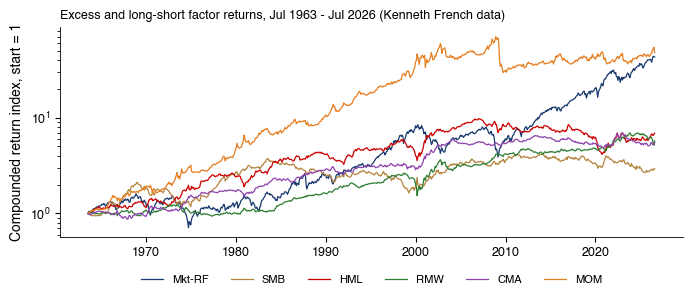

{'Mkt-RF': 43.163838074204776,
 'SMB': 2.9292806497668438,
 'HML': 6.881711823776164,
 'RMW': 5.733914451381408,
 'CMA': 5.486271239361806,
 'MOM': 47.97929331528067}

In [15]:
def fig_factor_cum():
    F = factors('M').loc[:END]
    cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    out = {}
    for c, col in zip(cols, [MainBlue, Amber, IDAred, Forest, Purple, Orange]):
        wealth = (1 + F[c]).cumprod()
        ax.plot(wealth.index, wealth.values, color=col, lw=0.9, label=c)
        out[c] = float(wealth.iloc[-1])
    ax.set_yscale('log')
    ax.set_ylabel('Compounded return index, start = 1')
    ax.set_title(f'Excess and long-short factor returns, {F.index[0]:%b %Y} - {F.index[-1]:%b %Y} (Kenneth French data)',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=6, y=-0.13)
    plt.tight_layout()
    save_fig('ch3_factor_cum')
    return out


fig_factor_cum()

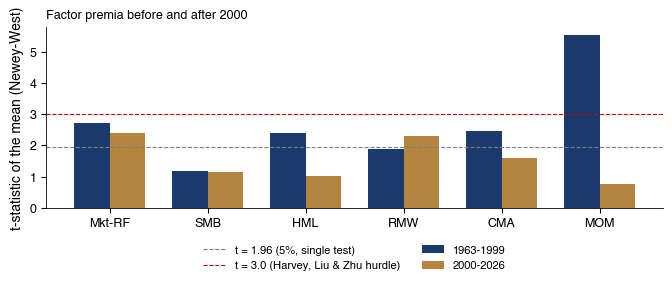

,factor,period,mean,t
0,Mkt-RF,1963-1999,0.069721,2.704993
1,Mkt-RF,2000-2026,0.074908,2.386048
2,SMB,1963-1999,0.023249,1.186117
3,SMB,2000-2026,0.021431,1.141446
4,HML,1963-1999,0.041915,2.394773
5,HML,2000-2026,0.027600,1.018865
6,RMW,1963-1999,0.020715,1.896612
7,RMW,2000-2026,0.044772,2.306803
8,CMA,1963-1999,0.031085,2.475194
9,CMA,2000-2026,0.027502,1.595391


In [16]:
def factor_tstats(split='1999-12-31'):
    F = factors('M').loc[:END]
    cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    rows = []
    for c in cols:
        for lab, x in [('1963-1999', F[c].loc[:split]), ('2000-2026', F[c].loc[split:].iloc[1:])]:
            b, se, t, _, _ = ols_hac(x.values, np.zeros((len(x), 0)))
            rows.append((c, lab, x.mean() * 12, t[0]))
    return pd.DataFrame(rows, columns=['factor', 'period', 'mean', 't'])


def fig_factor_tstats():
    d = factor_tstats()
    cols = d['factor'].unique()
    x = np.arange(len(cols))
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    for k, (lab, c) in enumerate([('1963-1999', MainBlue), ('2000-2026', Amber)]):
        v = d[d['period'] == lab].set_index('factor').loc[cols, 't']
        ax.bar(x + (k - 0.5) * 0.36, v.values, 0.36, color=c, label=lab)
    ax.axhline(1.96, color=Gray, ls='--', lw=0.8, label='t = 1.96 (5%, single test)')
    ax.axhline(3.0, color=IDAred, ls='--', lw=0.8, label='t = 3.0 (Harvey, Liu & Zhu hurdle)')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(x, cols)
    ax.set_ylabel('t-statistic of the mean (Newey-West)')
    ax.set_title('Factor premia before and after 2000', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save_fig('ch3_factor_tstats')
    return d


fig_factor_tstats()

### Comparing models: maximum Sharpe ratios (Barillas–Shanken)

- FF3 and Carhart use the published three-factor SMB; FF5 uses the five-factor SMB, so FF3 is not nested in FF5.
- Nested pairs (FF3 − CAPM, FF5 + MOM − FF5): the in-sample difference is never negative, so the percentile interval cannot contain 0 even when the added factors are useless; it is **not** a valid test of zero gain. Use the spanning alphas instead.
- The bootstrap intervals are informative only for the non-nested pairs (FF5 − FF3, FF5 − Carhart).

In [17]:
def max_sr2(F, fac):
    m = F[fac].mean().values
    V = np.atleast_2d(np.cov(F[fac].values.T))
    return float(m @ np.linalg.solve(V, m))


def stationary_bootstrap_idx(T, mean_block, rng):
    """Indices for the stationary bootstrap (Politis & Romano, 1994), mean block length mean_block."""
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(T)
    for t in range(1, T):
        idx[t] = rng.integers(T) if rng.random() < 1 / mean_block else (idx[t - 1] + 1) % T
    return idx


def model_comparison(B=2000, mean_block=6, seed=SEED):
    """Barillas & Shanken (2018): maximum squared Sharpe ratio of each model's factors; stationary-bootstrap intervals."""
    rng = np.random.default_rng(seed)
    F = factors('M')
    models = {'CAPM': ['Mkt-RF'], 'FF3': FF3, 'Carhart': CARHART, 'FF5': FF5, 'FF5+MOM': FF6}
    # nested pairs (FF3 - CAPM, FF5+MOM - FF5: in-sample difference >= 0) and non-nested pairs
    # (FF5 - FF3: different SMB in the two models; FF5 - Carhart)
    pairs = [('FF3', 'CAPM'), ('FF5', 'FF3'), ('FF5+MOM', 'FF5'), ('FF5', 'Carhart')]
    out = {}
    for lab, a, b in [('1963-2026', '1963-07-31', END), ('2000-2026', '2000-01-31', END)]:
        Fs = F.loc[a:b]
        T = len(Fs)
        sr2 = {k: max_sr2(Fs, v) for k, v in models.items()}
        boots = {p: [] for p in pairs}
        for _ in range(B):
            Fb = Fs.iloc[stationary_bootstrap_idx(T, mean_block, rng)]
            s = {k: max_sr2(Fb, v) for k, v in models.items()}
            for p in pairs:
                boots[p].append(12 * (s[p[0]] - s[p[1]]))
        # spanning alphas: each factor regressed on the other five (NW)
        full = models['FF5+MOM']
        span = {}
        for c in full:
            bb, se, t, _, _ = ols_hac(Fs[c].values, Fs[[x for x in full if x != c]].values)
            span[c] = dict(alpha=bb[0] * 12, t=t[0])
        out[lab] = dict(T=T, sr_ann={k: np.sqrt(12 * v) for k, v in sr2.items()},
                        sr2_ann={k: 12 * v for k, v in sr2.items()},
                        diff={f'{p[0]} - {p[1]}': dict(est=12 * (sr2[p[0]] - sr2[p[1]]),
                                                        ci=np.percentile(boots[p], [2.5, 97.5]).tolist(),
                                                        share_le0=float(np.mean(np.array(boots[p]) <= 0)))
                              for p in pairs},
                        spanning=span)
    return out


model_comparison()

{'1963-2026': {'T': 757,
  'sr_ann': {'CAPM': np.float64(0.465384221102935),
   'FF3': np.float64(0.6565549452302797),
   'Carhart': np.float64(0.9679685822893261),
   'FF5': np.float64(0.9663990619317022),
   'FF5+MOM': np.float64(1.163373133283511)},
  'sr2_ann': {'CAPM': 0.21658247325158547,
   'FF3': 0.4310643961063356,
   'Carhart': 0.9369631762992079,
   'FF5': 0.933927146902474,
   'FF5+MOM': 1.353437047245894},
  'diff': {'FF3 - CAPM': {'est': 0.2144819228547501,
    'ci': [0.028172310349037746, 0.6519806369842732],
    'share_le0': 0.0},
   'FF5 - FF3': {'est': 0.5028627507961384,
    'ci': [0.20624675075008164, 1.0710361102657362],
    'share_le0': 0.0},
   'FF5+MOM - FF5': {'est': 0.41950990034342,
    'ci': [0.10093274247154917, 0.9605656733810949],
    'share_le0': 0.0},
   'FF5 - Carhart': {'est': -0.003036029396733919,
    'ci': [-0.5705597928718039, 0.6635473634897837],
    'share_le0': 0.4555}},
  'spanning': {'Mkt-RF': {'alpha': np.float64(0.1054312666600487),
    't'

## 6. The factor zoo: 300 useless factors

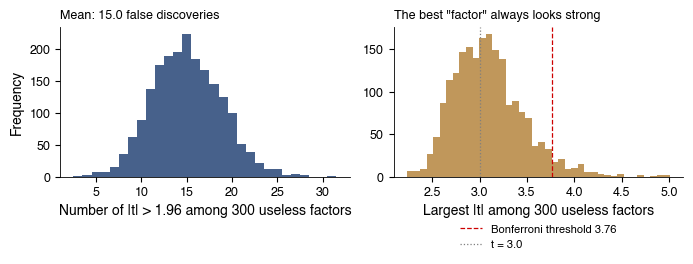

{'M': 300,
 'mean_n196': 15.0175,
 'mean_n3': 0.832,
 'median_tmax': 3.057760553531356,
 'bonf': 3.764823649533926,
 'p_any3': 0.5695}

In [18]:
def fig_false_discoveries(M=300, T=600, reps=2000):
    rng = np.random.default_rng(SEED)
    # M factors with no premium (mean 0), each tested on T months
    t = rng.standard_normal((reps, M))                 # t-statistic ~ N(0,1) under H0, independent tests
    n196 = (np.abs(t) > 1.96).sum(1)
    n3 = (np.abs(t) > 3.0).sum(1)
    tmax = np.abs(t).max(1)
    bonf = stats.norm.ppf(1 - 0.05 / (2 * M))
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9))
    axes[0].hist(n196, bins=np.arange(n196.min(), n196.max() + 2) - 0.5, color=MainBlue, alpha=0.8)
    axes[0].set_xlabel('Number of |t| > 1.96 among 300 useless factors')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Mean: {n196.mean():.1f} false discoveries', fontsize=9, loc='left')
    axes[1].hist(tmax, bins=40, color=Amber, alpha=0.85)
    axes[1].axvline(bonf, color=IDAred, ls='--', lw=0.9, label=f'Bonferroni threshold {bonf:.2f}')
    axes[1].axvline(3.0, color=Gray, ls=':', lw=0.9, label='t = 3.0')
    axes[1].set_xlabel('Largest |t| among 300 useless factors')
    axes[1].set_title('The best "factor" always looks strong', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=1, y=-0.25)
    plt.tight_layout()
    save_fig('ch3_false_discoveries')
    return dict(M=M, mean_n196=float(n196.mean()), mean_n3=float(n3.mean()), median_tmax=float(np.median(tmax)),
                bonf=float(bonf), p_any3=float((n3 > 0).mean()))


fig_false_discoveries()

## 7. Latent factors: PCA of US sector ETFs

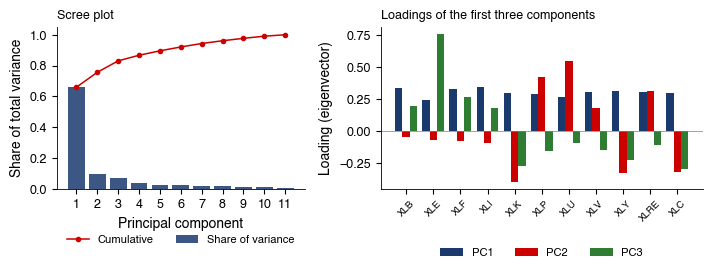

{'start': '2018-06-20',
 'end': '2026-09-18',
 'T': 2073,
 'share': [0.6598485852014292,
  0.0967418826785423,
  0.0742696512685773,
  0.036276040707513814,
  0.028787802265608294],
 'cum3': 0.8308601191485488,
 'corr_pc1_spy': 0.9539639295054083,
 'load_pc2': {'XLB': np.float64(-0.051),
  'XLE': np.float64(-0.072),
  'XLF': np.float64(-0.078),
  'XLI': np.float64(-0.096),
  'XLK': np.float64(-0.398),
  'XLP': np.float64(0.418),
  'XLU': np.float64(0.549),
  'XLV': np.float64(0.176),
  'XLY': np.float64(-0.332),
  'XLRE': np.float64(0.309),
  'XLC': np.float64(-0.326)},
 'load_pc1': {'XLB': np.float64(0.332),
  'XLE': np.float64(0.241),
  'XLF': np.float64(0.329),
  'XLI': np.float64(0.339),
  'XLK': np.float64(0.293),
  'XLP': np.float64(0.285),
  'XLU': np.float64(0.262),
  'XLV': np.float64(0.303),
  'XLY': np.float64(0.313),
  'XLRE': np.float64(0.307),
  'XLC': np.float64(0.299)}}

In [19]:
def pca_sectors():
    S = [s + '.US' for s in SECTORS_ALL]
    r = log_returns(prices(S + ['SPY.US']))
    X = r[S]
    Z = (X - X.mean()) / X.std()
    C = np.corrcoef(Z.values.T)
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    for k in range(vecs.shape[1]):                      # sign: positive mean loading
        if vecs[:, k].sum() < 0:
            vecs[:, k] *= -1
    pcs = Z.values @ vecs
    corr_pc1_spy = np.corrcoef(pcs[:, 0], r['SPY.US'].values)[0, 1]
    return vals, vecs, r, corr_pc1_spy


def fig_pca():
    vals, vecs, r, c1 = pca_sectors()
    share = vals / vals.sum()
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={'width_ratios': [1, 1.3]})
    k = np.arange(1, len(vals) + 1)
    axes[0].bar(k, share, color=MainBlue, alpha=0.85, label='Share of variance')
    axes[0].plot(k, np.cumsum(share), color=IDAred, marker='o', ms=3, label='Cumulative')
    axes[0].set_xlabel('Principal component')
    axes[0].set_ylabel('Share of total variance')
    axes[0].set_xticks(k)
    axes[0].set_title('Scree plot', fontsize=9, loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.22)
    x = np.arange(len(SECTORS_ALL))
    for j, c in enumerate([MainBlue, IDAred, Forest]):
        axes[1].bar(x + (j - 1) * 0.27, vecs[:, j], 0.27, color=c, label=f'PC{j + 1}')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xticks(x, SECTORS_ALL, rotation=45, fontsize=7)
    axes[1].set_ylabel('Loading (eigenvector)')
    axes[1].set_title('Loadings of the first three components', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=3, y=-0.3)
    plt.tight_layout()
    save_fig('ch3_pca')
    return dict(start=str(r.index[0].date()), end=str(r.index[-1].date()), T=len(r),
                share=[float(s) for s in share[:5]], cum3=float(share[:3].sum()), corr_pc1_spy=float(c1),
                load_pc2=dict(zip(SECTORS_ALL, np.round(vecs[:, 1], 3))),
                load_pc1=dict(zip(SECTORS_ALL, np.round(vecs[:, 0], 3))))


fig_pca()

### How many factors? Kaiser, Bai–Ng and Ahn–Horenstein

In [20]:
def n_factors(X, kmax):
    """Number of factors: Kaiser (eigenvalues > 1), Bai & Ng (2002) IC_p2, Ahn & Horenstein (2013) ER."""
    X = np.asarray(X, float)
    X = (X - X.mean(0)) / X.std(0)
    T, N = X.shape
    ev = np.sort(np.linalg.eigvalsh(X.T @ X / T))[::-1]         # eigenvalues of the correlation matrix
    V = [ev[k:].sum() / N for k in range(kmax + 1)]              # V(k) = (1/NT) sum of squared residuals
    pen = (N + T) / (N * T) * np.log(min(N, T))
    ic = [np.log(V[k]) + k * pen for k in range(kmax + 1)]
    er = [ev[k - 1] / ev[k] for k in range(1, kmax + 1)]
    return dict(T=T, N=N, kaiser=int((ev > 1).sum()), bai_ng=int(np.argmin(ic)),
                ahn_horenstein=int(np.argmax(er) + 1), eig=ev[:kmax + 1].round(3).tolist(),
                er=np.round(er, 2).tolist())


def number_of_factors():
    """Number-of-factors estimators on the sector ETFs (daily) and on 100 portfolios (monthly)."""
    vals, vecs, r, c1 = pca_sectors()
    S = [s + '.US' for s in SECTORS_ALL]
    out = {'sectors': n_factors(r[S].values, 5)}
    P = french('p100', 'M').loc['1963-07-31':END].dropna(axis=1)
    F = factors('M').loc[P.index]
    out['p100'] = n_factors(P.sub(F['RF'], axis=0).values, 8)
    return out


number_of_factors()

{'sectors': {'T': 2073,
  'N': 11,
  'kaiser': 2,
  'bai_ng': 5,
  'ahn_horenstein': 1,
  'eig': [7.258, 1.064, 0.817, 0.399, 0.317, 0.275],
  'er': [6.82, 1.3, 2.05, 1.26, 1.15]},
 'p100': {'T': 757,
  'N': 95,
  'kaiser': 3,
  'bai_ng': 4,
  'ahn_horenstein': 1,
  'eig': [70.899, 4.865, 3.085, 0.89, 0.655, 0.522, 0.485, 0.434, 0.393],
  'er': [14.57, 1.58, 3.47, 1.36, 1.25, 1.08, 1.12, 1.1]}}

## 8. Factor investing: factor ETFs, their growth and their alphas

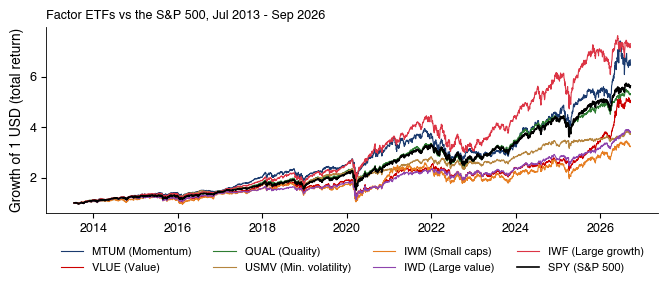

{'start': '2013-07-18',
 'cagr': {'MTUM': 0.15501271636210756,
  'VLUE': 0.13090712217448797,
  'QUAL': 0.13542910146314502,
  'USMV': 0.10500583723814261,
  'IWM': 0.09322036712947179,
  'IWD': 0.1069093487845969,
  'IWF': 0.16313245149221034,
  'SPY': 0.14036040990013188}}

In [21]:
def fig_factor_etfs():
    E = [e + '.US' for e in FACTOR_ETFS] + ['SPY.US']
    p = prices(E)
    wealth = p / p.iloc[0]
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    names = {'MTUM': 'Momentum', 'VLUE': 'Value', 'QUAL': 'Quality', 'USMV': 'Min. volatility',
             'IWM': 'Small caps', 'IWD': 'Large value', 'IWF': 'Large growth', 'SPY': 'S&P 500'}
    out = {}
    for e, c in zip(E, PALETTE):
        k = e[:-3]
        ax.plot(wealth.index, wealth[e].values, color=c if k != 'SPY' else 'black', lw=0.8 if k != 'SPY' else 1.2,
                label=f'{k} ({names[k]})')
        yrs = (p.index[-1] - p.index[0]).days / 365.25
        out[k] = float(wealth[e].iloc[-1] ** (1 / yrs) - 1)
    ax.set_ylabel('Growth of 1 USD (total return)')
    ax.set_title(f'Factor ETFs vs the S&P 500, {p.index[0]:%b %Y} - {p.index[-1]:%b %Y}', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.13)
    plt.tight_layout()
    save_fig('ch3_factor_etfs')
    return dict(start=str(p.index[0].date()), cagr=out)


fig_factor_etfs()

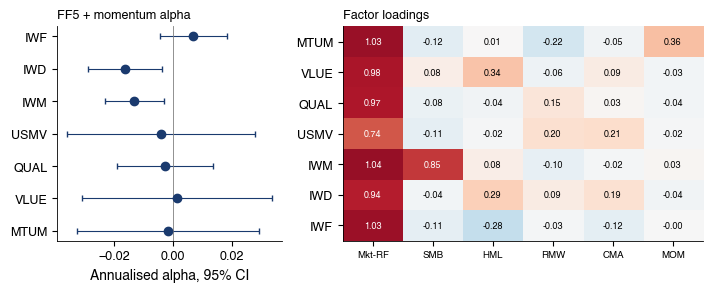

{'start': '2000-05-30',
 'end': '2026-07-31',
 'n_min': 3194,
 'n_max': 6582,
 'table': [{'etf': 'MTUM',
   'alpha': -0.002,
   'se_alpha': 0.016,
   't_alpha': -0.11,
   'r2': 0.905,
   'n': 3338,
   'Mkt-RF': 1.034,
   'SMB': -0.123,
   'HML': 0.007,
   'RMW': -0.221,
   'CMA': -0.046,
   'MOM': 0.36},
  {'etf': 'VLUE',
   'alpha': 0.001,
   'se_alpha': 0.016,
   't_alpha': 0.079,
   'r2': 0.886,
   'n': 3194,
   'Mkt-RF': 0.983,
   'SMB': 0.076,
   'HML': 0.342,
   'RMW': -0.064,
   'CMA': 0.095,
   'MOM': -0.035},
  {'etf': 'QUAL',
   'alpha': -0.003,
   'se_alpha': 0.008,
   't_alpha': -0.34,
   'r2': 0.963,
   'n': 3276,
   'Mkt-RF': 0.975,
   'SMB': -0.078,
   'HML': -0.044,
   'RMW': 0.145,
   'CMA': 0.025,
   'MOM': -0.037},
  {'etf': 'USMV',
   'alpha': -0.004,
   'se_alpha': 0.016,
   't_alpha': -0.252,
   'r2': 0.81,
   'n': 3703,
   'Mkt-RF': 0.742,
   'SMB': -0.105,
   'HML': -0.017,
   'RMW': 0.196,
   'CMA': 0.211,
   'MOM': -0.015},
  {'etf': 'IWM',
   'alpha': -0.013,

In [22]:
def etf_regressions():
    E = [e + '.US' for e in FACTOR_ETFS]
    rows, span = [], []
    for e in E:
        y, F = daily_excess_one(e)
        X = F[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']].values
        b, se, t, _, r2 = ols_hac(y.values, X, lags=10)
        rows.append([e[:-3], b[0] * 252, se[0] * 252, t[0], r2, len(y)] + list(b[1:]))
        span.append((y.index[0], y.index[-1]))
    cols = ['etf', 'alpha', 'se_alpha', 't_alpha', 'r2', 'n', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    return pd.DataFrame(rows, columns=cols).set_index('etf'), span


def fig_etf_alphas():
    res, span = etf_regressions()
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={'width_ratios': [1, 1.6]})
    y = np.arange(len(res))
    axes[0].errorbar(res['alpha'], y, xerr=1.96 * res['se_alpha'], fmt='o', color=MainBlue, capsize=2, lw=0.8)
    axes[0].axvline(0, color=Gray, lw=0.6)
    axes[0].set_yticks(y, res.index)
    axes[0].set_xlabel('Annualised alpha, 95% CI')
    axes[0].set_title('FF5 + momentum alpha', fontsize=9, loc='left')
    L = res[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']]
    im = axes[1].imshow(L.values, cmap='RdBu_r', vmin=-1.2, vmax=1.2, aspect='auto')
    axes[1].set_xticks(range(L.shape[1]), L.columns, fontsize=7)
    axes[1].set_yticks(y, res.index)
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            axes[1].text(j, i, f'{L.values[i, j]:.2f}', ha='center', va='center', fontsize=6.5,
                         color='white' if abs(L.values[i, j]) > 0.6 else 'black')
    axes[1].set_title('Factor loadings', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch3_etf_alphas')
    return dict(start=str(min(a for a, b in span).date()), end=str(max(b for a, b in span).date()),
                n_min=int(res['n'].min()), n_max=int(res['n'].max()),
                table=res.round(3).reset_index().to_dict(orient='records'))


fig_etf_alphas()

## Conclusions

- On the 25 size × B/M portfolios the security market line is flat or negative and the GRS test rejects the CAPM.
- Betas need robust standard errors, change over time and regress towards one.
- Value and profitability carry cross-sectional premia on the 25 portfolios, but the cross-sectional $R^2$ collapses once industries are added; errors must be robust to estimated betas and to misspecification.
- Hundreds of factors require multiple-testing hurdles; PCA recovers the market as the first latent factor.
- Factor ETFs deliver their exposures, with alphas close to zero.